# Notebook for testing spot characterization code on star images.

Initially written 10 Jan 2020 by Craig Lage.\
Adapted 16 Mar 21 to run on star images. \
Modeling the PSF as a 2D Gaussian.\

In [1]:
import sys, os, glob, time
import pickle as pkl
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import astropy.io.fits as pf
from scipy.optimize import fmin_powell
from scipy.special import erf
#sys.path.append(os.path.realpath('/home/cslage/alternate_branches/Poisson_CCD/pysrc/forward_model_varying_i'))
#import forward

import lsst.afw.image as afwImage
import lsst.geom as geom
from lsst.daf.persistence import Butler
from lsst.ip.isr.isrFunctions import brighterFatterCorrection
from lsst.meas.algorithms import SourceDetectionTask
from lsst.pipe.tasks.characterizeImage import CharacterizeImageTask, CharacterizeImageConfig

In [2]:
# Classes to put the data
class Array2dSet:
    def __init__(self,xmin,xmax,nx,ymin,ymax,ny,nstamps):
        # This packages up a set of nstamps postage stamp images,
        # each image of which is nx * ny pixels
        self.nx=nx
        self.ny=ny
        self.nstamps=nstamps

        self.xmin=xmin
        self.ymin=ymin
        
        self.xmax=xmax
        self.ymax=ymax
        
        self.dx=(xmax-xmin)/nx
        self.dy=(ymax-ymin)/ny
        
        self.x=np.linspace(xmin+self.dx/2,xmax-self.dx/2,nx)
        self.y=np.linspace(ymin+self.dy/2,ymax-self.dy/2,ny)

        self.data=np.zeros([nx,ny,nstamps])
        self.xoffset=np.zeros([nstamps])
        self.yoffset=np.zeros([nstamps])
        self.imax=np.zeros([nstamps])


def BuildSpotList(array, x_centroids, y_centroids, nx, ny):
    stampxmin = -(int(nx/2)+0.5)
    stampxmax = -stampxmin
    stampymin = -(int(ny/2)+0.5)
    stampymax = -stampymin
    numspots = len(x_centroids)
    spotlist = Array2dSet(stampxmin,stampxmax,nx,stampymin,stampymax,ny,numspots)
    n=0
    for xcen,ycen in zip(x_centroids, y_centroids):
        xint = int(round(xcen))
        yint = int(round(ycen))
        xmin = xint - int(nx/2)
        xmax = xint + int(nx/2) + 1
        ymin = yint - int(ny/2)
        ymax = yint + int(ny/2) + 1
        stamp = array[ymin:ymax, xmin:xmax]
        # Now recenter to the spot maximum
        ind = np.unravel_index(np.argmax(stamp, axis=None), stamp.shape)
        yint = yint + ind[0] - int((ny-1) / 2)
        xint = xint + ind[1] - int((nx-1) / 2)
        xmin = xint - int(nx/2)
        xmax = xint + int(nx/2) + 1
        ymin = yint - int(ny/2)
        ymax = yint + int(ny/2) + 1
        stamp = array[ymin:ymax, xmin:xmax]
        xsum = 0.0
        ysum = 0.0
        datasum = 0.0
        
        for i in range(nx):
            for j in range(ny):
                spotlist.data[i,j,n] = float(stamp[j,i])  

        for i in range(nx):
            for j in range(ny):
                spotlist.data[i,j,n] = float(stamp[j,i])                    
                ysum += spotlist.y[j] * spotlist.data[i,j,n]
                xsum += spotlist.x[i] * spotlist.data[i,j,n]
                datasum += spotlist.data[i,j,n]
        xoff = xsum / datasum
        yoff = ysum / datasum
        spotlist.xoffset[n] = xoff
        spotlist.yoffset[n] = yoff
        
        n += 1
    return spotlist

#def FOM(params):
#    [sigmax, sigmay] = params
#    result = forward.forward(spotlist,sigmax,sigmay)
#    return result

def PyFOM(params):
    # Modified this to also fit for the X,Y offsets
    fom = 0.0
    [Imax, sigmax, sigmay, xoff, yoff] = params
    area=np.zeros([spotlist.nx,spotlist.ny])
   
    for spot in range(spotlist.nstamps):
        for ii in range(spotlist.nx):
            for jj in range(spotlist.ny):
                xl = spotlist.x[ii] - xoff - 0.5
                xh = xl + 1.0
                yl = spotlist.y[jj] - yoff - 0.5
                yh = yl + 1.0
                area[ii,jj] = Area(xl, xh, yl, yh, sigmax, sigmay, Imax)
                fom += np.square(area[ii,jj]-spotlist.data[ii,jj,spot])
    return fom


def Area(xl, xh, yl, yh, sigmax, sigmay, Imax):
    # Calculates how much of a 2D Gaussian falls within a rectangular box
    ssigx = np.sqrt(2.0) * sigmax
    ssigy = np.sqrt(2.0) * sigmay    
    I = (erf(xh/ssigx)-erf(xl/ssigx))*(erf(yh/ssigy)-erf(yl/ssigy))
    return Imax * I / 4.0

In [3]:
REPO_DIR = '/project/shared/auxTel/rerun/quickLook'
DETECTOR = 0

In [4]:
# Now set up the charConfig 
butler = Butler(REPO_DIR)
charConfig = CharacterizeImageConfig()
charConfig.doMeasurePsf = True
charConfig.doApCorr = False
charConfig.doDeblend = False
charConfig.repair.doCosmicRay = True
charConfig.repair.doInterpolate = True   
charConfig.detection.minPixels = 500
charTask = CharacterizeImageTask(config=charConfig)

/opt/lsst/software/stack/stack/miniconda3-py38_4.9.2-0.4.1/Linux64/obs_lsst/21.0.0-14-gd6c32a3+ca5ab316ea/python/lsst/obs/lsst/lsstCamMapper.py:157: FutureWarning: Replaced by FilterLabel. Will be removed after v22.
  for n in afwImage.Filter.getNames():
/opt/lsst/software/stack/stack/miniconda3-py38_4.9.2-0.4.1/Linux64/obs_lsst/21.0.0-14-gd6c32a3+ca5ab316ea/python/lsst/obs/lsst/lsstCamMapper.py:157: FutureWarning: Replaced by FilterLabel. Will be removed after v22.
  for n in afwImage.Filter.getNames():
/opt/lsst/software/stack/stack/miniconda3-py38_4.9.2-0.4.1/Linux64/obs_lsst/21.0.0-14-gd6c32a3+ca5ab316ea/python/lsst/obs/lsst/lsstCamMapper.py:157: FutureWarning: Replaced by FilterLabel. Will be removed after v22.
  for n in afwImage.Filter.getNames():


In [5]:
# First lok at an image with basically one bright star
expId=2021031100184
exp = butler.get('quickLookExp', detector=DETECTOR, expId=expId)
charResult = charTask.run(exp)
sourceCatalog = charResult.sourceCat
print(f"Found {len(sourceCatalog)} sources")

Ignoring translator header fixup of LATISS AT_O_20210311_000184: 'MJD-OBS not found'


Found 36 sources


In [6]:
# Pick the brightest source
maxFlux = np.nanmax(sourceCatalog['base_SdssShape_instFlux'])
selectBrightestSource = sourceCatalog['base_SdssShape_instFlux'] > maxFlux * 0.99
brightestSource = sourceCatalog.subset(selectBrightestSource)
print(f"Brightest source with flux = {maxFlux} is at \
    ({brightestSource['base_SdssCentroid_x'][0]}, {brightestSource['base_SdssCentroid_y'][0]}).")


Brightest source with flux = 49461568.872045755 is at     (1783.875165448295, 1794.8462732603239).


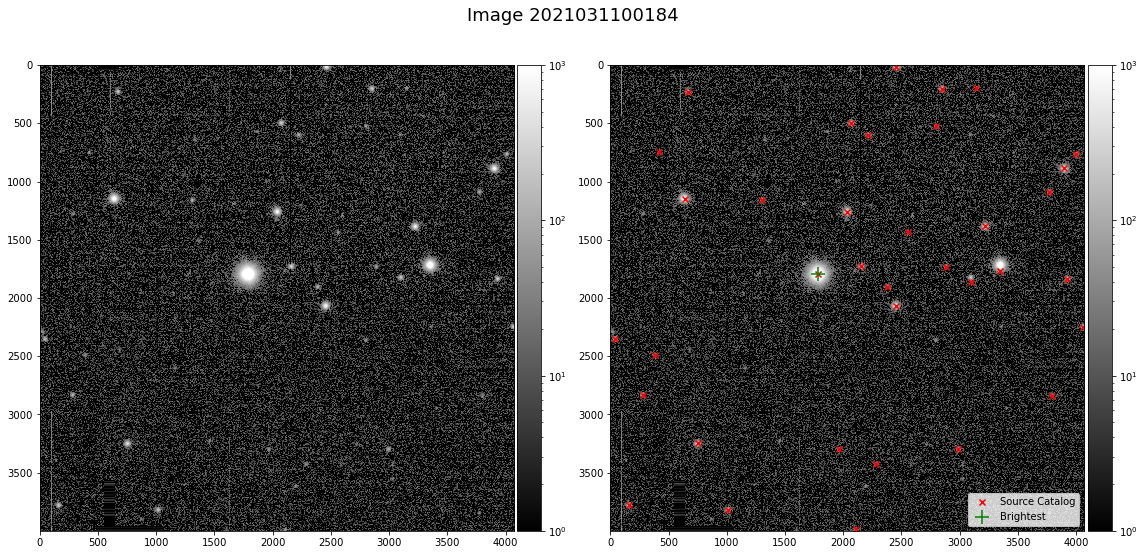

In [16]:
# Look at the data with matplotlib
# Overlay the sourceCatalog with red x's
# It found most source, but not all
from matplotlib.colors import LogNorm
# Now let's look at them
def colorbar(mappable):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    plt.sca(last_axes)
    return cbar

plt.figure(figsize=(16,8))
plt.suptitle(f"Image {expId}",fontsize=18)
plt.subplot(1,2,1)
arr = exp.image.array
arr = np.clip(arr, 1, 100000) # This image has some negative values, and this removes them
img = plt.imshow(arr, norm=LogNorm(vmin=1, vmax=1000),  interpolation='Nearest', cmap='gray')
colorbar(img)
plt.subplot(1,2,2)
img = plt.imshow(arr, norm=LogNorm(vmin=1, vmax=1000),  interpolation='Nearest', cmap='gray')
plt.scatter(sourceCatalog['base_SdssCentroid_x'],sourceCatalog['base_SdssCentroid_y']\
            ,color='red', marker='x', label='Source Catalog')
plt.scatter(brightestSource['base_SdssCentroid_x'],brightestSource['base_SdssCentroid_y']\
            ,color='green', marker='+', s=200, label = 'Brightest')
plt.legend()

colorbar(img)
plt.tight_layout(h_pad=1)
plt.savefig("/home/craiglagegit/DATA/%s_Sources.png"%expId)

In [8]:
# Let's try running my forward modeling routine on a single star
xs = brightestSource['base_SdssCentroid_x']
ys = brightestSource['base_SdssCentroid_y']
nx = ny = 75 # stamp size
spotlist = BuildSpotList(exp.image.array, xs, ys, nx, ny)
print("nstamps = %d"%spotlist.nstamps)

nstamps = 1


In [9]:
param0 = [8.0E7, 10.0, 10.0, 2.0, 2.0]
args = ()

starttime = time.time()
Result = fmin_powell(PyFOM, param0, args)
elapsed = time.time() - starttime

print(Result, spotlist.imax[0], elapsed)
#print(spotlist.xoffset)
print(spotlist.nstamps)
# Why are xoff and yoff > 1.0???

Optimization terminated successfully.
         Current function value: 45223154918.099937
         Iterations: 3
         Function evaluations: 167
[4.94429478e+07 1.01585124e+01 1.06674667e+01 1.96203597e+00
 1.90719596e+00] 0.0 13.306816339492798
1


49442947.804260015 1.3027911109012273
1.4208891390692073 1.3867849896189959
Sum = 57366571.47, Max = 87987.5


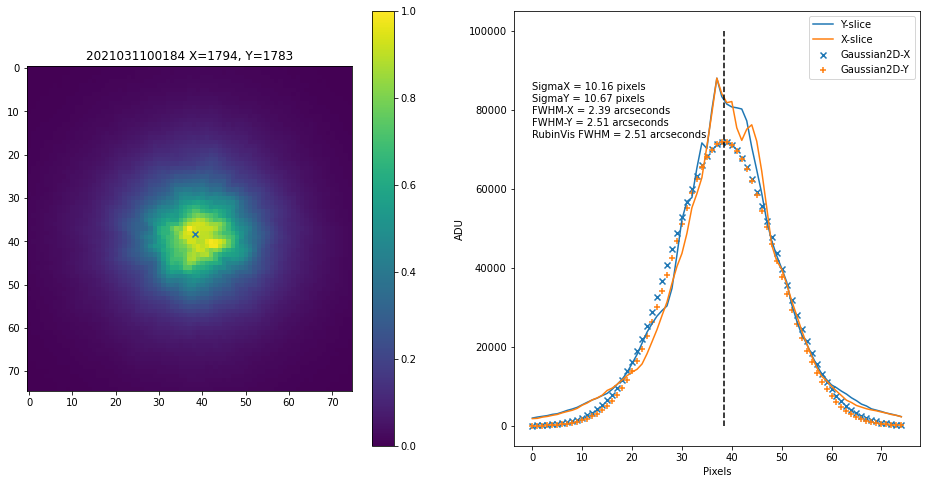

In [18]:
# Now plot the fit
plateScale = 0.1
sigmaToFWHM = 2.355
spotNum = 0

plotX = range(nx)
sigmax = Result[1]
sigmay = Result[2]
#sigmax = Result[0]
#sigmay = Result[1]

area=np.zeros([nx,ny])
Imax = Result[0]
for ii in range(nx):
    for jj in range(ny):
        xl = ii - int((nx-1)/2) - spotlist.xoffset[spotNum] - 0.5
        xh = xl + 1.0
        yl = jj - int((ny-1)/2) - spotlist.yoffset[spotNum] - 0.5
        yh = yl + 1.0
        area[ii,jj] = Area(xl, xh, yl, yh, sigmax, sigmay, Imax)

print(Imax, area[4,4])
print(spotlist.xoffset[spotNum],spotlist.yoffset[spotNum])

plt.figure(figsize=(16,8))    
plt.subplot(1,2,1)
plt.title("%d X=%d, Y=%d"%(expId, ys[spotNum], xs[spotNum]))
plt.imshow(spotlist.data[:,:,spotNum])
plt.scatter([int((nx-1)/2) + spotlist.xoffset[spotNum]], [int((ny-1)/2) + spotlist.yoffset[spotNum]], marker='x')
plt.colorbar()

plt.subplot(1,2,2)
plt.plot(spotlist.data[int((nx-1)/2),:,spotNum], label = "Y-slice")
plt.plot(spotlist.data[:,int((ny-1)/2),spotNum], label = "X-slice")
plt.plot([int((nx-1)/2) + spotlist.xoffset[spotNum],int((nx-1)/2) + spotlist.xoffset[spotNum]],\
         [0,100000],ls='--', color='black')
plt.scatter(plotX,area[int((nx-1)/2),:], marker='x', label = 'Gaussian2D-X')
plt.scatter(plotX,area[:,int((ny-1)/2)], marker='+', label = 'Gaussian2D-Y')
plt.text(0,85000, f"SigmaX = {Result[1]:.2f} pixels")
plt.text(0,82000, f"SigmaY = {Result[2]:.2f} pixels")

plt.text(0,79000, f"FWHM-X = {Result[1]*plateScale*sigmaToFWHM:.2f} arcseconds")
plt.text(0,76000, f"FWHM-Y = {Result[2]*plateScale*sigmaToFWHM:.2f} arcseconds")
plt.text(0,73000, "RubinVis FWHM = 2.51 arcseconds")
print("Sum = %.2f, Max = %.1f"%(spotlist.data[:,:,spotNum].sum(), spotlist.data[:,:,spotNum].max()))
plt.xlabel("Pixels")
plt.ylabel("ADU")
plt.legend()
plt.savefig("/home/craiglagegit/DATA/%s_BrightestFit.png"%expId)
